In [1]:
using Pkg
Pkg.activate("../tambo/")
using Tambo
using JLD2
using StatsBase
using Plots
using StaticArrays
using Glob 
using Measures
using Dierckx

  Activating project at `~/Documents/physics/TAMBO/tambo`


In [31]:
config.tambo_coordinates

(-15.62227°, -72.2794°)

In [2]:
using QuadGK

In [3]:
TAMBO_PATH = "../Tambo"
# This should be the simulation parameters jld2 file

#path to sim file
SIMULATION_FILE = "/Users/pavelzhelnin/Documents/physics/TAMBO/resources/Larger_Valley/sim_files/larger_valley_00000_00023.jld2"

sim = jldopen(SIMULATION_FILE)
config = SimulationConfig(; geo_spline_path="../resources/tambo_spline.jld2", filter(x->x[1]!=:geo_spline_path, sim["config"])...)
geo = Tambo.Geometry(config)
injector = Tambo.Injector(config)
plane = Tambo.Plane(config.plane_orientation, config.tambo_coordinates,geo)
size = SVector{3}([2,2,0.03])*units.m
altmin = 2300units.m
altmax = 3700units.m
modules = Tambo.make_detector_array(
    5000units.m,
    150units.m,
    altmin,
    altmax,
    plane,
    geo,
    size,
)
nmodules = length(modules)

hard_SIMULATION_FILE = "/Users/pavelzhelnin/Documents/physics/TAMBO/resources/Larger_Valley/hard_spectrum/sim_files/larger_valley_00000_00023.jld2"
hard_sim = jldopen(hard_SIMULATION_FILE)
hard_config = SimulationConfig(; geo_spline_path="../resources/tambo_spline.jld2", filter(x->x[1]!=:geo_spline_path, hard_sim["config"])...)
hard_injector = Tambo.Injector(hard_config)

Tambo.Injector(n=20000
seed=443
ν_pdg=16
interaction=CC
xs_model=csms
γ=1.0
emin=300000.0 GeV
emax=1.0e9 GeV
θmin=50.0°
θmax=117.0°
ϕmin=90.0°
ϕmax=290.0°
r_injection=2000.0 m 
l_endcap=1000.0 m
xs_dir=/Users/pavelzhelnin/Documents/physics/TAMBO/resources/cross_sections/tables
, PowerLaw(γ=1.0, emin=300000.0 GeV, emax=1.0e9 GeV), Tambo.CrossSection(16, Tambo.CC, OutgoingEnergy(fname=/Users/pavelzhelnin/Documents/physics/TAMBO/resources/cross_sections/tables/csms_differential_cross_section_cdf.h5, interaction=CC, emin=10.0 GeV), TotalXS(fname=/Users/pavelzhelnin/Documents/physics/TAMBO/resources/cross_sections/tables/csms_total_cross_section.h5, interaction=CC), DifferentialXS(fname=/Users/pavelzhelnin/Documents/physics/TAMBO/resources/cross_sections/tables/csms_differential_cross_section.h5, interaction=CC, emin=10.0 GeV)), UniformAngularSampler(θmin=50.0∘, θmax=117.0∘, ϕmin=90.0∘, ϕmax=290.0∘), r_injection (m): 2000.0
l_endcap (m): 1000.0
, Geometry(Tambo.Valley(Spline2D([0.0, 0.0, 0.

In [36]:
rad2deg(plane.n̂.θ)

31.22788675141436

In [4]:
#path to files 
file_names = ["retest_normal*.jld2","retest_small*jld2","retest_medium*jld2"]
num_files = 50
# for E^-2 spectrum
#simfiles = glob("larger*jld2","/Users/pavelzhelnin/Documents/physics/TAMBO/resources/Larger_Valley/sim_files")[1:num_files]
#files = glob(file_names[2],"/Users/pavelzhelnin/Documents/physics/TAMBO/resources/airshowers/big_showers/triggered_showers")[1:num_files]

# for E^-1 spectrum 
simfiles = glob("larger*jld2","/Users/pavelzhelnin/Documents/physics/TAMBO/resources/Larger_Valley/hard_spectrum/sim_files")[1:num_files]
files = glob(file_names[2],"/Users/pavelzhelnin/Documents/physics/TAMBO/resources/Larger_Valley/hard_spectrum/triggered_files")[1:num_files]

50-element Vector{String}:
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00001_triggered_events.jld2"
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00002_triggered_events.jld2"
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00003_triggered_events.jld2"
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00004_triggered_events.jld2"
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00005_triggered_events.jld2"
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00006_triggered_events.jld2"
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00007_triggered_events.jld2"
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00008_triggered_events.jld2"
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00009_triggered_events.jld2"
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00010_triggered_events.jld2"
 ⋮
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00042_triggered_events.jld2"
 "/Users/pavelzhelnin/Documents/p" ⋯ 96 bytes ⋯ "000_00043_triggered

In [5]:
function load_events(files)
    all_events = Vector{Tambo.InjectionEvent}()
    #det config has to be configured 
    for file in files
        triggered_events = load(file)["5000.0_150.0"]
        append!(all_events, triggered_events)
    end
    return all_events 
end 

load_events (generic function with 1 method)

In [6]:
function combined_calc_triggered_event_rate(triggered_events; γ, ϕ, norm_e)
    norm = ϕ / units.GeV / units.cm^2 / units.second * (1 /(norm_e))^-γ
    pl = Tambo.PowerLaw(γ, 100units.GeV, 1e9units.GeV, norm)
    fluxes = pl.(triggered_events["initial_state"]["energy"])
    both_injectors = Vector{Tambo.Injector}([injector, hard_injector])
    both_injectors_xs = Vector{Tambo.CrossSection}([injector.xs, hard_injector.xs])
    wgts = [oneweight(triggered_event, both_injectors, both_injectors_xs) / (length(files)*config.n) for triggered_event in triggered_events]  # FIXME hack
    #wgts = oneweight.(triggered_events, Ref(injector), Ref(injector.xs)) ./ 20000
    global_fit_rates = fluxes .* wgts
    return global_fit_rates, wgts
end

combined_calc_triggered_event_rate (generic function with 1 method)

In [7]:
IC_EHE_EA = [
1204709.5495477326, 21892.34459834299,
1476106.34505762, 36092.026991718005,
1870935.5342795674, 74944.37457206589,
3056990.7009353717, 203693.43663782632,
4436687.330978607, 439547.95420151314,
5166962.315798257, 1895229.4462087215,
5916417.643667467, 3006625.4683717145,
6774579.645621405, 2679013.781976757,
8024385.134607399, 1823729.1257388254,
9188302.698631069, 1241497.1309382224,
11450475.699382812, 1447943.3336802504,
15795355.751478795, 1969532.9767360468,
21423101.870379984, 2679013.781976757,
44366873.30978607, 4769763.748207339,
84424906.48167099, 7863499.552142407,
225393390.47347936, 16968564.122928895,
633097484.9403919, 36616288.52201103,
2216094292.844441, 79013909.21553871,
22539339047.347843, 231923345.78844655,
5529005969.372227, 130263441.2370901,
]

40-element Vector{Float64}:
      1.2047095495477326e6
  21892.34459834299
      1.47610634505762e6
  36092.026991718005
      1.8709355342795674e6
  74944.37457206589
      3.0569907009353717e6
 203693.43663782632
      4.436687330978607e6
 439547.95420151314
      ⋮
      1.6968564122928895e7
      6.330974849403919e8
      3.661628852201103e7
      2.216094292844441e9
      7.901390921553871e7
      2.2539339047347843e10
      2.3192334578844655e8
      5.529005969372227e9
      1.302634412370901e8

In [8]:
IC_EA= [] # log scale in eV
IC_energy_GeV = [] # not log scale in GeV
for (i,x) in enumerate(IC_EHE_EA)
    if i%2 == 1
        push!(IC_energy_GeV, x)
    else
        push!(IC_EA, x)
    end
end 

In [9]:
IC_EA = IC_EA  * (2/3) * 1e-4 * 4π

20-element Vector{Float64}:
     18.340487722669476
     30.23638582675888
     62.785252422262374
    170.64581443356084
    368.2348330186391
   1587.7437080203656
   2518.8246622753463
   2244.365337686397
   1527.843739615688
   1040.0742042688867
   1213.0261706411172
   1649.9920881911469
   2244.365337686397
   3995.907933527224
   6587.709979871257
  14215.551037482865
  30675.590139326425
  66194.53779278595
 194295.6478199864
 109129.24533913813

Total rate over 10 years

In [10]:
e1_files = glob(file_names[2],"/Users/pavelzhelnin/Documents/physics/TAMBO/resources/Larger_Valley/hard_spectrum/triggered_files")
e2_files = glob(file_names[2],"/Users/pavelzhelnin/Documents/physics/TAMBO/resources/airshowers/big_showers/triggered_showers")

e1_all_events = load_events(e1_files)
e2_all_events = load_events(e2_files)

e_all_events = append!(e1_all_events, e2_all_events)

e_triggered_events, e_wgts = combined_calc_triggered_event_rate(e_all_events; γ=2.5, ϕ=1.8e-18, norm_e=100units.TeV)

ten_year_rate = sum(e_triggered_events) * (5000/nmodules) * 10 * 10^7.5 * units.second 

display("New Valley Location: $(ten_year_rate)")

"New Valley Location: 5.12121800270727"

In [11]:
Rod=[1010667.4874293355, 1.4401769029678594e-9,
1465205.760749628, 1.5073628992941169e-9,
2124168.3818230075, 1.6140641521538906e-9,
3281927.872511464, 1.8089465828118465e-9,
5638350.552739181, 2.432980420037399e-9,
9383183.950023482, 3.751953313824305e-9,
15287335.514400577, 6.33840810154468e-9,
28288694.34625961, 1.1465841675756172e-8,
50707140.98062063, 1.728318435121521e-8,
86195356.64752997, 2.0741095118420868e-8,
144974067.03726286, 2.1219379168489426e-8,
246436520.9960373, 1.8089465828118463e-8,
470772471.97407776, 1.0707867049863933e-8,
766995165.8566236, 5.655555225142397e-9,
1043357590.0342635, 3.4249439246819883e-9,
1389495494.3731303, 1.8506604023110204e-9,
1792487852.5659187, 9.554281212853708e-10,
2239909206.2212105, 4.821346193585806e-10,
2711313418.9525995, 2.3781411280961385e-10,
3213012701.5963917, 1.1207402013097774e-10,
3688249366.5608726, 5.655555225142398e-11]

42-element Vector{Float64}:
 1.0106674874293355e6
 1.4401769029678594e-9
 1.465205760749628e6
 1.5073628992941169e-9
 2.1241683818230075e6
 1.6140641521538906e-9
 3.281927872511464e6
 1.8089465828118465e-9
 5.638350552739181e6
 2.432980420037399e-9
 ⋮
 9.554281212853708e-10
 2.2399092062212105e9
 4.821346193585806e-10
 2.7113134189525995e9
 2.3781411280961385e-10
 3.2130127015963917e9
 1.1207402013097774e-10
 3.6882493665608726e9
 5.655555225142398e-11

In [17]:
Rod_E,Rod_E2_Phi = data_loader(Rod)
Rod_Phi = (Rod_E2_Phi ./ Rod_E.^2)
Rod_spl = Spline1D(Rod_E,Rod_Phi)

Spline1D(knots=[1.01067e6,2.12417e6 … 2.71131e9,3.68825e9] (19 elements), k=3, extrapolation="nearest", residual=0.0)

In [18]:
VanVilet = [1088595.0606821151, 7.267518376864185e-11,
1545041.2973828544, 1.0466512108254224e-10,
2654380.227569437, 1.6893621992017852e-10,
3848162.970540382, 2.220928889966334e-10,
5945570.70854437, 2.9197558324778924e-10,
10106674.874293355, 3.584721705777592e-10,
14966326.223296117, 4.0175417261727235e-10,
19306977.288832456, 4.401131616874802e-10,
25986425.410137188, 5.046267831325145e-10,
35349811.05030095, 6.634102514187433e-10,
47579443.140093945, 9.338928054889355e-10,
58207233.51294732, 1.2277470827878667e-9,
75889961.3766639, 1.8089465828118465e-9,
92841454.45194726, 2.432980420037399e-9,
131769733.68542142, 4.2049649122403555e-9,
164660663.7589129, 5.785970800743581e-9,
214682792.13338962, 8.145000008709273e-9,
274023632.0766271, 1.0466512108254224e-8,
388921320.0654648, 1.473386993275716e-8,
512480587.6960905, 1.768172991317254e-8,
689778537.9387616, 2.1708692319540546e-8,
1043357590.0342635, 2.432980420037394e-8,
1262939331.0982966, 2.4890842912355695e-8,
1528733551.4400578, 2.4890842912355695e-8,
2014408129.492257, 2.4890842912355695e-8,
2544075255.6199327, 2.432980420037394e-8,
3460752225.999825, 2.272142910168375e-8,
4911840318.133487, 2.027359157379187e-8,
6752943055.966238, 1.768172991317254e-8,
9483278946.857481, 1.473386993275716e-8,
]

60-element Vector{Float64}:
 1.0885950606821151e6
 7.267518376864185e-11
 1.5450412973828544e6
 1.0466512108254224e-10
 2.654380227569437e6
 1.6893621992017852e-10
 3.848162970540382e6
 2.220928889966334e-10
 5.94557070854437e6
 2.9197558324778924e-10
 ⋮
 2.432980420037394e-8
 3.460752225999825e9
 2.272142910168375e-8
 4.911840318133487e9
 2.027359157379187e-8
 6.752943055966238e9
 1.768172991317254e-8
 9.483278946857481e9
 1.473386993275716e-8

In [19]:
VV_E, VV_E2_Phi = data_loader(VanVilet)
VV_Phi = (VV_E2_Phi ./ VV_E.^2)
VV_spl = Spline1D(VV_E,VV_Phi)

Spline1D(knots=[1.0886e6,2.65438e6 … 4.91184e9,9.48328e9] (28 elements), k=3, extrapolation="nearest", residual=0.0)

In [20]:
function spline_calc_triggered_event_rate(triggered_events; spline)
    fluxes = (1/3)*spline(triggered_events["initial_state"]["energy"]/units.GeV) / units.GeV / units.cm^2 / units.second
    both_injectors = Vector{Tambo.Injector}([injector, hard_injector])
    both_injectors_xs = Vector{Tambo.CrossSection}([injector.xs, hard_injector.xs])
    wgts = [oneweight(triggered_event, both_injectors, both_injectors_xs) / (length(files)*config.n) for triggered_event in triggered_events]  # FIXME hack
    global_fit_rates = fluxes .* wgts
    return global_fit_rates, wgts
end

spline_calc_triggered_event_rate (generic function with 1 method)

In [21]:
function data_loader(array)
    IC_EA = [] # log scale in eV
    IC_energy_GeV = [] # not log scale in GeV
    for (i,x) in enumerate(array)
        if i%2 == 1
            push!(IC_energy_GeV, x)
        else
            push!(IC_EA, x)
        end
    end 
    return IC_energy_GeV, IC_EA
end 

data_loader (generic function with 1 method)

In [22]:
function combine_adjacent_elements(arr)
    combined = []
    i = 1
    while i < length(arr)
        push!(combined, arr[i] + arr[i+1])
        # Alternatively, for string concatenation, you could use: push!(combined, string(arr[i]) * string(arr[i+1]))
        i += 2
    end
    
    # If the length of 'arr' is odd, add the last element as it is
    if isodd(length(arr))
        push!(combined, arr[end])
    end
    
    return combined
end

combine_adjacent_elements (generic function with 1 method)

In [23]:
Glashow_EA = [0.0, 0.0, 0.0, 0.0046816482044159495, 0.03713849798996347, 0.0739791408876635, 0.16322523978243142, 0.34027495622777654, 0.7334218313716241, 1.4473454167634539, 3.2348105831290495, 9.68887819318819, 37.94437758512714, 318.72949073974775, 5016.674414469627, 247.44682564367457, 97.07277582928188, 48.33559469984019, 26.2860132574856, 18.250634229930935, 18.512188665180652, 14.112834563170725, 8.066685692391541, 9.282281252955308, 1.4721553044072142, 6.056621969146591, 12.432071583190375, 0.02860029252080212, 2.198576437495593, 0.0, 3.4431868274079775, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
combined_G_EA = combine_adjacent_elements(Glashow_EA)
glashow_edges = 10 .^ (14:0.125:19)
glashow_cents = (glashow_edges[1:end-1] .+ glashow_edges[2:end]) / 2
Glashow_spl = Spline1D(log10.(glashow_cents[4:end-13]), log10.(Glashow_EA[4:end-13]))
#Glashow_wgts = Glashow_EAs .* diff(edges) .* units.m^2 * (5000/nmodules) 

Spline1D(knots=[14.442,14.692 … 17.067,17.317] (22 elements), k=3, extrapolation="nearest", residual=0.0)

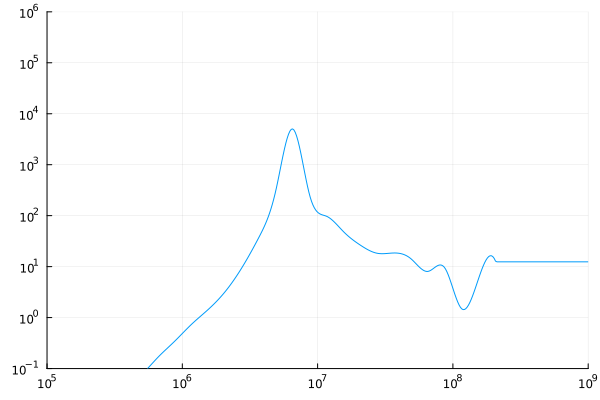

In [24]:
GW_edges = 10 .^ (14:0.01:19)
GW_cents = (GW_edges[1:end-1] .+ GW_edges[2:end]) / 2
plot(
    GW_cents/1e9, 
    10 .^Glashow_spl(log10.(GW_cents)), 
    yscale=:log10, 
    xscale=:log10,
    label="",
    xlimits=(1e5, 1e9),
    ylimits=(1e-1, 1e6)
    )

In [25]:
norm_e = 100units.TeV
γ = 2.52 
ϕ = 1.8e-18 / 2
norm = ϕ / units.GeV / units.cm^2 / units.second * (1 /(norm_e))^-γ
pl = Tambo.PowerLaw(γ, 100units.GeV, 1e9units.GeV, norm)
new_glashow_edges = 10 .^(14:0.01:17)
new_glashow_cents = (new_glashow_edges[1:end-1] .+ new_glashow_edges[2:end]) / 2
#fluxes = pl.(new_glashow_cents) 
#GR_rates = fluxes .* (10 .^Glashow_spl(log10.(new_glashow_cents)) .* diff(new_glashow_edges) .* units.m^2) * units.second * 10 * 10^7.5
sum([quadgk(x-> 10 .^Glashow_spl(log10.(x)) * ϕ * (x/100units.TeV)^-γ * 1e4 * 1e-9, new_glashow_edges[i],new_glashow_edges[i+1])[1] for i in 1:length(new_glashow_edges)-1])*10*10^7.5
#sum(GR_rates)


0.7077084340694129

Effective Area Calculation

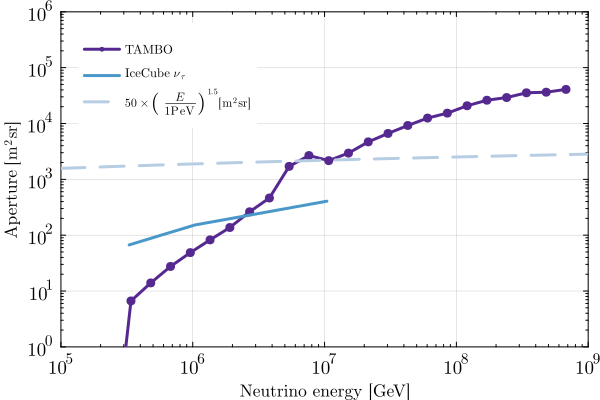

"/Users/pavelzhelnin/Documents/physics/TAMBO/notebooks/tambo-acceptance.pdf"

In [30]:
EA_plt = plot(
    xscale=:log,
    yscale=:log,
    xlabel="Neutrino energy [GeV]",
    xminorticks=true,
    yminorticks=true,
    ylabel="Aperture \$ [\\textnormal{m^{2}sr}] \$",
    xlimits=(1e5, 1e9),
    ylimits=(1e0, 1e6),
    legend=:topleft,
    framestyle=:box,
    # left_margin=5mm,
    # top_margin=5mm,
    # right_margin=5mm,
    # bottom_margin=5mm,
    fontfamily="Computer Modern",
    tickfontsize=12,
    palette= cgrad(:BuPu_9,8,categorical=true)[3:7],
    foreground_color_legend = nothing,
    size=(600, 400)   
)


#edges = 10 .^ (14:0.15:18)
edges = 10 .^ (14:0.15:18)
cents = (edges[1:end-1] .+ edges[2:end]) / 2

label = "Triggered Effective Areas"
hist_three = fit(Histogram, e_all_events["initial_state"]["energy"], Weights(e_wgts), edges)
Glashow_EAs = 10 .^Glashow_spl(log10.(cents))
EA_colors = cgrad(:BuPu_9,8,categorical=true)

plot!(
    EA_plt,
    cents / units.GeV,
    (hist_three.weights ./ diff(edges) ./units.m^2 * (5000/nmodules)) + Glashow_EAs,
    #linetype=:stepmid,
    #label="TAMBO \$ \\nu_\\tau + \\bar \\nu_\\tau + \\bar \\nu_e\$",
    label="TAMBO",
    marker=:circle,
    msw=0,
    markersize=5,
    color=cgrad(:Purples,16,categorical=true,rev=true)[3],
    #legend=:bottomright,
    title="",
    lw=3
    )

# plot!(
#     EA_plt,
#     cents / units.GeV,
#     (hist_three.weights ./ diff(edges) ./units.m^2 * (5000/nmodules)),
#     msw=0,
#     #linetype=:stepmid,
#     label="TAMBO \$ \\nu_\\tau + \\bar \\nu_\\tau \$",
#     marker=:circle,
#     markersize=5,
#     color=:mediumblue,
#     #legend=:bottomright,
#     title="",
#     lw=3
#     )

# plot!(
#     EA_plt,
#     cents[6:10] / units.GeV,
#     Glashow_EAs[6:10],
#     #linetype=:stepmid,
#     label="TAMBO \$ \\bar \\nu_e \$",
#     marker=:circle,
#     markersize=5,
#     #legend=:bottomright,
#     title="",
#     lw=3
#     )

f(x) = 150 * (x/1e15)^0.4
function IC_tau(x)
    if x < 1e15
        return 65*(x/3.16e14)^0.72
    else
        return 150 * (x/1e15)^0.425
    end
end
f(x) = IC_tau(x)
#f(x) = 150 * (x/1e15)^0.7
# Generate the data points

ic_edges = 10 .^ (14.375:0.25:16.25)
ic_cents = (ic_edges[1:end-1] .+ ic_edges[2:end]) / 2

icecube = f.(ic_cents)     # Broadcast the function f over the array x
plot!(EA_plt, ic_cents/units.GeV,icecube,
#color=EA_colors[end-3],
color=cgrad(:Blues,16,categorical=true,rev=true)[7],
lw=3,label="IceCube \$ \\nu_\\tau \$")
# plot!(IC_energy_GeV,IC_EA,lw=3,linestyle=:dashdot,label="IceCube \$ \\nu_\\tau \$ (EHE)")
# plot!([energy_GeV],[acceptance_romero],lw=3, label="Romero-Wolf")

param_norm = 50
f(x) = param_norm * (x/1e15)^1.5
f(x) = 2200/7 * log10(x/1e9)
# Generate the data points
EA_cents = 10 .^ (14.0:0.25:19.0)
y = f.(EA_cents)     # Broadcast the function f over the array x
plot!(EA_plt, EA_cents/units.GeV,y,
lw=3,
color=EA_colors[end-5],
linestyle=:dash,
label="\$ $(param_norm) \\times \\left( \\frac{E}{\\textnormal{1 PeV}} \\right)^{1.5} \\textnormal{[m^{2}sr]}\$")

display(EA_plt)
savefig(EA_plt,"tambo-acceptance.pdf")

In [73]:
quadgk(x->IC_tau(x)*1.8e-27*(x/100units.TeV)^-2.5*1e4,1e15,2e16)[1] * 10^7.5

0.24113170236984804

Comparison in rates between IceCube extrapolated and max allowed UHE flux 

In [85]:
function plot_many_spectra(flux_labels)

    plt = plot(
    xscale=:log10,
    yscale=:log10,
    xlabel="Neutrino energy (GeV)",
    xminorticks=true,
    yminorticks=true,
    ylabel="Number of events in TAMBO (10 yr)",
    xlimits=(3e5, 1e9),
    xticks=[1e6,1e7,1e8,1e9],
    ylimits=(1e-2, 1e2),
    legend=:topleft,
    framestyle=:box,
    tickfontsize=12,
    title = "",
    # left_margin=5mm,
    # right_margin=5mm,
    # bottom_margin=5mm,
    fontfamily="Computer Modern",
    #legendtitlefonthalign=:center,
    #legendtitle="Cosmic Neutrino Flux",
    legendtitlefontsize=8,
    size=(600, 400)   
    ) 

    colors = cgrad(:BuPu_9,length(flux_labels)+1,categorical=true,rev=true)[1:length(flux_labels)]
    
    for (idx,flux_label) in enumerate(flux_labels)
        
        display(flux_label)
        e_triggered_events, e_wgts = combined_calc_triggered_event_rate(e_all_events; γ=2.52, ϕ=1.8e-18, norm_e=100units.TeV)
        spl = spline_mauricio(flux_label)
        triggered_events,_ = spline_calc_triggered_event_rate(e_all_events; spline=spl)
        total_triggered_events = triggered_events + e_triggered_events
        total_events_per_10years_5kdetectors = sum(total_triggered_events) * (5000/nmodules) * 10 * 10^7.5 * units.second
        display("total events for $(flux_label): $(total_events_per_10years_5kdetectors)")
        energies = e_all_events["initial_state"]["energy"]

        edges = 10 .^ (14:0.5:19)
        cents = (edges[1:end-1] .+ edges[2:end]) / 2

        UHE_errors = Float64[]
        astro_errors = Float64[] 

        for (idx,edge) in enumerate(edges[1:end-1])
            mask = edge .< energies .< edges[idx+1]
            wgt = e_wgts[mask]
            
            if length(energies[mask]) == 0
                new_rates = Float64[] 
                astro_error = sqrt(sum(new_rates.^2))
                push!(UHE_errors,astro_error)
                continue
            end

            astro_rates = combined_calc_triggered_event_rate(e_all_events[mask]; γ=2.52, ϕ=1.8e-18, norm_e=100units.TeV)[1]
            VV_rates,_ = spline_calc_triggered_event_rate(e_all_events[mask]; spline=spl)
            VV_new_rates = astro_rates .+ VV_rates
            VV_error = sqrt(sum(VV_new_rates.^2))
            astro_error = sqrt(sum(astro_rates.^2))

            push!(astro_errors,astro_error)
            push!(UHE_errors,VV_error)
        end

        formated_number = round(total_events_per_10years_5kdetectors,sigdigits=2)
        hist_wp = fit(Histogram, energies, Weights(total_triggered_events), edges)

        ugh = sum(UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules)
        ugh = round(ugh, sigdigits=1)   
        #label = "$(flux_label) \$\\nu\$ $(formated_number) ± $(ugh) events/10yr"
        label = get_flux_label(flux_label)

        down = (hist_wp.weights .- UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules)
        down[down .< 0] .= 1e-29

        plot!(
            plt,
            edges / units.GeV,
            hist_wp.weights .* units.second * 10*10^7.5 .* (5_000 / nmodules),
            linetype=:stepbins,
            label=label,
            c=colors[idx],
            lw=3
            )

        plot!(
            plt, 
            edges / units.GeV,
            down,
            linetype=:stepbins,
            lw=2,
            label="",
            c=colors[idx],
            )

        plot!(
            plt, 
            edges / units.GeV,
            (hist_wp.weights .+ UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules), 
            linetype=:stepbins,
            lw=2,
            label="",
            c=colors[idx],
            )

        plot!(
            edges / units.GeV,
            down; 
            fillrange=(hist_wp.weights .+ UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules), 
            fillalpha=0.35,
            c=colors[idx],
            label="",
            seriestype=:barbins,
            lw=0
        )

    end 
    
    savefig(plt, "both-tambo-spectra.svg")
    return plt 
end 

plot_many_spectra (generic function with 1 method)

In [86]:
cosmo_flux_labels

UndefVarError: UndefVarError: `cosmo_flux_labels` not defined

In [87]:
plot_many_spectra(both_flux_labels)

UndefVarError: UndefVarError: `both_flux_labels` not defined

In [88]:
function get_flux_label(flux_label::String)::String
    if flux_label == "heinze_zmax_1"
        return "Heinze \$\\it{et~al.}\$, fit to Auger UHECRs"
    elseif flux_label == "rodrigues_bench_cosmo"
        return "Rodrigues \$\\it{et~al.}\$, all AGN"
    elseif flux_label == "rodrigues_bench_source"
        return "Rodrigues \$\\it{et~al.}\$, all AGN"
    elseif flux_label == "rodrigues_hlbllacs_cosmo"
        return "Rodrigues \$\\it{et~al.}\$, HL BL Lacs"
    elseif flux_label == "fang_murase"
        return "Fang & Murase, cosmic-ray reservoirs"
    elseif flux_label == "van_vliet_ta"
        return "Bergman & van Vliet, fit to TA UHECRs"
    elseif flux_label == "padovani_2015"
        return "Padovani \$\\it{et~al.}\$, BL Lacs"
    elseif flux_label == "fang_pulsar_sfr"
        return "Fang \$\\it{et~al.}\$, newborn pulsars"
    elseif flux_label == "muzio_2019"
        return "Muzio \$\\it{et~al.}\$, maximum extra \$p\$ component"
    elseif flux_label == "muzio_2021"
        return "Muzio \$\\it{et~al.}\$, cosmic ray-gas interactions"
    else
        return flux_label
    end
end

get_flux_label (generic function with 1 method)

In [396]:
pl(1e15/1e9) * units.GeV * units.cm^2 * units.second

130.0895793671335

"Van Vilet: 7.927957134756245"

"Rod: 15.707567121894499"

"IC extrapolated: 4.7262894483235645"

0.7077472200513495

"Van Vilet: 8.3"

...

"Rod: 19.0"

"IC: 5.4"

10-element Vector{Float64}:
 0.03456604191863042
 0.891892819664388
 1.0562263827214649
 1.7530891291200978
 0.919905729750814
 0.5182938165109524
 0.2024495796465056
 0.05761129134805328
 1.599698301222716e-6
 2.7799570336138036e-7

11-element Vector{Float64}:
 100000.0
 316227.76601683797
      1.0e6
      3.1622776601683795e6
      1.0e7
      3.162277660168379e7
      1.0e8
      3.1622776601683795e8
      1.0e9
      3.1622776601683793e9
      1.0e10

10-element Vector{Float64}:
 0.0391666791674934
 0.9179784323457001
 1.0985817414010526
 2.1619521980771776
 1.066097029203681
 0.8643959756151228
 1.3556313257751471
 1.7353489158463475
 0.0011039236893717406
 0.0002862299800544846

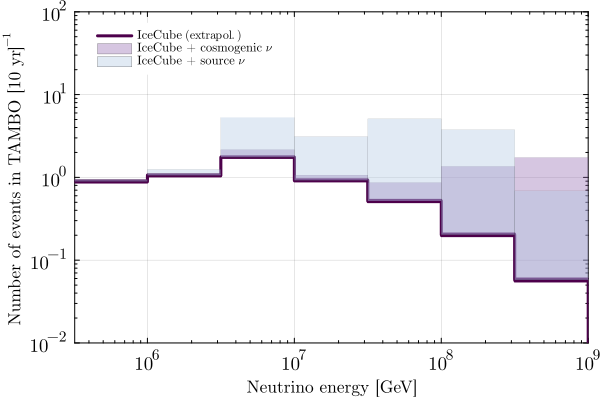

"/Users/pavelzhelnin/Documents/physics/TAMBO/notebooks/2models_diffuse_rates.svg"

In [183]:
e_triggered_events, e_wgts = combined_calc_triggered_event_rate(e_all_events; γ=2.52, ϕ=1.8e-18, norm_e=100units.TeV)

#cosmo_triggered_events,_ = combined_calc_triggered_event_rate(e_all_events; γ=1, ϕ=9.26e-23, norm_e=4.9units.PeV)
VV_triggered_events, VV_wgts = spline_calc_triggered_event_rate(e_all_events; spline=VV_spl)
Rod_triggered_events, Rod_wgts = spline_calc_triggered_event_rate(e_all_events; spline=Rod_spl)

VV_UHE_triggered_events = VV_triggered_events + e_triggered_events
Rod_UHE_triggered_events = Rod_triggered_events + e_triggered_events
#UHE_triggered_events = cosmo_triggered_events + e_triggered_events

#UHE_events_per_10years_5kdetectors = sum(UHE_triggered_events) * (5000/nmodules) * 10 * 10^7.5 * units.second
VV_UHE_events_per_10years_5kdetectors = sum(VV_UHE_triggered_events) * (5000/nmodules) * 10 * 10^7.5 * units.second
dashed_VV_UHE_events_per_10years_5kdetectors = sum(VV_triggered_events) * (5000/nmodules) * 10 * 10^7.5 * units.second
Rod_UHE_events_per_10years_5kdetectors = sum(Rod_UHE_triggered_events) * (5000/nmodules) * 10 * 10^7.5 * units.second
dashed_Rod_UHE_events_per_10years_5kdetectors = sum(Rod_triggered_events) * (5000/nmodules) * 10 * 10^7.5 * units.second
IC_extrapolated_events_per_10years_5kdetectors = sum(e_triggered_events) * (5000/nmodules) * 10 * 10^7.5 * units.second

display("Van Vilet: $(VV_UHE_events_per_10years_5kdetectors)")
display("Rod: $(Rod_UHE_events_per_10years_5kdetectors)")

#display("combined event rate: $UHE_events_per_10years_5kdetectors")
display("IC extrapolated: $IC_extrapolated_events_per_10years_5kdetectors")

energies = e_all_events["initial_state"]["energy"]

plt = plot(
xscale=:log10,
yscale=:log10,
xlabel="Neutrino energy [GeV]",
xminorticks=true,
yminorticks=true,
ylabel="Number of events in TAMBO [10 yr\$]^{-1}\$",
xlimits=(3.2e5, 1e9),
xticks=[1e6,1e7,1e8,1e9],
ylimits=(1e-2, 1e2),
legend=:topleft,
framestyle=:box,
tickfontsize=12,
# left_margin=5mm,
# right_margin=5mm,
bottom_margin=2mm,
fontfamily="Computer Modern",
#legendtitlefonthalign=:center,
#legendtitle="Cosmic Neutrino Flux",
legendtitlefontsize=8,
foreground_color_legend = nothing,
size=(600, 400)   
) 

edges = 10 .^ (14:0.5:19)
cents = (edges[1:end-1] .+ edges[2:end]) / 2

GR_rates_VV = [quadgk(x-> 10 .^Glashow_spl(log10(x)) * (1/6) * VV_spl(x/1e9) / 1e4, edges[i],edges[i+1])[1] for i in 1:length(edges)-1]*10*10^7.5
GR_rates_Rod = [quadgk(x-> 10 .^Glashow_spl(log10(x)) * (1/6) * Rod_spl(x/1e9) / 1e4, edges[i],edges[i+1])[1] for i in 1:length(edges)-1]*10*10^7.5
GR_rates_IC = [quadgk(x-> 10 .^Glashow_spl(log10(x)) * pl(x) * 1e4 * 1e-9 * units.GeV * units.cm^2 * units.second, edges[i],edges[i+1])[1] for i in 1:length(edges)-1]*10*10^7.5
display(sum(GR_rates_IC))
#GR_rates_IC = pl.(cents) .* (10 .^Glashow_spl(log10.(cents)) .* diff(edges) .* units.m^2) * units.second * 10 * 10^7.5

VV_UHE_events_per_10years_5kdetectors += sum(GR_rates_VV)
dashed_VV_UHE_events_per_10years_5kdetectors += sum(GR_rates_VV)
Rod_UHE_events_per_10years_5kdetectors += sum(GR_rates_Rod)
dashed_Rod_UHE_events_per_10years_5kdetectors += sum(GR_rates_Rod)
IC_extrapolated_events_per_10years_5kdetectors += sum(GR_rates_IC)

hist_wp = fit(Histogram, energies, Weights(e_wgts), edges)

VV_UHE_errors = Float64[]
Rod_UHE_errors = Float64[]
#UHE_errors=Float64[]
astro_errors = []

colors = cgrad(:BuPu_9,4,categorical=true,rev=true)[1:3]

for (idx,edge) in enumerate(edges[1:end-1])
    mask = edge .< energies .< edges[idx+1]
    wgt = e_wgts[mask]
    
    if length(energies[mask]) == 0
        VV_new_rates = Float64[] 
        Rod_new_rates = Float64[]
        astro_rates = Float64[]
        astro_error = sqrt(sum(astro_rates.^2))
        VV_error = sqrt(sum(VV_new_rates.^2))
        Rod_error = sqrt(sum(Rod_new_rates.^2))
           
        #push!(UHE_errors,error)
        push!(VV_UHE_errors,VV_error)
        push!(Rod_UHE_errors,Rod_error)
        push!(astro_errors,astro_error)
        continue
    end
    astro_rates = combined_calc_triggered_event_rate(e_all_events[mask]; γ=2.52, ϕ=1.8e-18, norm_e=100units.TeV)[1]
    VV_rates = spline_calc_triggered_event_rate(e_all_events[mask]; spline=VV_spl)[1]
    Rod_rates = spline_calc_triggered_event_rate(e_all_events[mask]; spline=Rod_spl)[1]
    
    VV_new_rates = astro_rates .+ VV_rates
    Rod_new_rates = astro_rates .+ Rod_rates


    astro_error = sqrt(sum(astro_rates.^2))
    VV_error = sqrt(sum(VV_new_rates.^2))
    Rod_error = sqrt(sum(Rod_new_rates.^2))
       
    push!(VV_UHE_errors,VV_error)
    push!(Rod_UHE_errors,Rod_error)
    push!(astro_errors,astro_error)
end
 
#UHE_formated_number = round(UHE_events_per_10years_5kdetectors,sigdigits=3)
VV_formated_number = round(VV_UHE_events_per_10years_5kdetectors,sigdigits=2)
Rod_formated_number = round(Rod_UHE_events_per_10years_5kdetectors,sigdigits=2)
IC_formated_number = round(IC_extrapolated_events_per_10years_5kdetectors,sigdigits=2)
dashed_Rod_formated_number = round(dashed_Rod_UHE_events_per_10years_5kdetectors,sigdigits=2)
dashed_VV_formated_number = round(dashed_VV_UHE_events_per_10years_5kdetectors,sigdigits=2)

display("Van Vilet: $(VV_formated_number)")
display("Van Vilet: $(VV_UHE_events_per_10years_5kdetectors)")
display("Rod: $(Rod_formated_number)")
display("IC: $(IC_formated_number)")


hist_wp = fit(Histogram, energies, Weights(VV_UHE_triggered_events), edges) 
dashed_hist_wp = fit(Histogram, energies, Weights(VV_triggered_events), edges) 
hist_wp_Rod = fit(Histogram, energies, Weights(Rod_UHE_triggered_events), edges) 
dashed_hist_wp_Rod = fit(Histogram, energies, Weights(Rod_triggered_events), edges) 
hist_wp_calc = fit(Histogram, energies, Weights(e_triggered_events), edges)

ugh = sum(VV_UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules)
ugh = round(ugh, sigdigits=1) 
dashed_ugh = round(ugh/2,sigdigits=1)
#label = "IceCube + Cosmogenic \$\\nu\$ $(VV_formated_number) ± $(ugh) events/10yr"
label = "IceCube + Cosmogenic \$\\nu\$"
#dashed_label = "Cosmogenic \$\\nu\$ $(dashed_VV_formated_number) ± $(dashed_ugh) events/10yr"
dashed_label = "Cosmogenic \$\\nu\$ (Bergman & van Vliet, fit to TA UHECRs)"

calc_ugh = sum(astro_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules)
calc_ugh = round(calc_ugh, sigdigits=1)
#calc_label = "IceCube \$ \\textnormal{(extrapol.)} \$: $(IC_formated_number) ± $(calc_ugh) events/10yr"
calc_label = "IceCube \$ \\textnormal{(extrapol.)} \$"

Rod_ugh = sum(Rod_UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules)
Rod_ugh = round(Rod_ugh, sigdigits=1)
dashed_Rod_ugh = round(Rod_ugh/1.2,sigdigits=1)
#Rod_label = "IceCube + Source \$\\nu\$ $(Rod_formated_number) ± $(Rod_ugh) events/10yr"
Rod_label = "IceCube + Source \$\\nu\$"
dashed_Rod_label = "Source \$\\nu\$ (Rodrigues \$\\it{et~al.}\$, all AGN)"

down = (hist_wp.weights .- VV_UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules)
down[down .< 0] .= 1e-29

calc_down = (hist_wp_calc.weights .- astro_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules)
calc_down[calc_down .< 0] .= 1e-29

Rod_down = (hist_wp_Rod.weights .- Rod_UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules)
Rod_down[Rod_down .< 0] .= 1e-29

display((hist_wp_calc.weights .* units.second * 10*10^7.5 .* (5_000 / nmodules)) .+ GR_rates_IC)
display(edges/units.GeV)
display((hist_wp.weights .+ VV_UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules) .+ GR_rates_VV .+ GR_rates_IC)
plot!(
    plt, 
    edges / units.GeV,
    (hist_wp_calc.weights .* units.second * 10*10^7.5 .* (5_000 / nmodules)) .+ GR_rates_IC,
    linetype=:stepbins,
    label=calc_label,
    c=colors[1],
    lw=3
    )

# plot!(
#     plt,
#     edges / units.GeV,
#     hist_wp.weights .* units.second * 10*10^7.5 .* (5_000 / nmodules) .+ GR_rates_VV .+ GR_rates_IC,
#     linetype=:stepbins,
#     #label=label,
#     label="",
#     c=colors[2],
#     lw=3
#     )

# plot!(
#     plt,
#     edges / units.GeV,
#     dashed_hist_wp.weights .* units.second * 10*10^7.5 .* (5_000 / nmodules) .+ GR_rates_VV,
#     linetype=:stepbins,
#     linestyle=:dash,
#     label=dashed_label,
#     c=colors[2],
#     lw=3
#     )

# plot!(
#     plt, 
#     edges / units.GeV,
#     hist_wp_Rod.weights .* units.second * 10*10^7.5 .* (5_000 / nmodules) .+ GR_rates_Rod .+ GR_rates_IC,
#     linetype=:stepbins,
#     label=Rod_label,
#     c=colors[3],
#     lw=3
# )

# plot!(
#     plt, 
#     edges / units.GeV,
#     dashed_hist_wp_Rod.weights .* units.second * 10*10^7.5 .* (5_000 / nmodules) .+ GR_rates_Rod,
#     linetype=:stepbins,
#     linestyle=:dash,
#     label=dashed_Rod_label,
#     c=colors[3],
#     lw=3
# )


# plot!(
#     plt, 
#     edges / units.GeV,
#     down .+ GR_rates_VV .+ GR_rates_IC,
#     linetype=:stepbins,
#     lw=2,
#     label="",
#     c =colors[2]
#     )

plot!(
    plt, 
    edges / units.GeV,
    calc_down.+ GR_rates_IC,
    linetype=:stepbins,
    lw=2,
    label="",
    c = colors[1]
    )

# plot!(
#     plt, 
#     edges / units.GeV,
#     Rod_down .+ GR_rates_Rod .+ GR_rates_IC,
#     linetype=:stepbins,
#     lw=2,
#     label="",
#     c = colors[3]
# )

plot!(
plt, 
edges / units.GeV,
((hist_wp_calc.weights .+ astro_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules)).+GR_rates_IC, 
linetype=:stepbins,
lw=2,
label="",
c = colors[1]
)

# plot!(
# plt, 
# edges / units.GeV,
# (hist_wp_Rod.weights .+ Rod_UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules).+GR_rates_Rod .+ GR_rates_IC, 
# linetype=:stepbins,
# lw=2,
# label="",
# c = colors[3]
# )

# plot!(
# plt, 
# edges / units.GeV,
# (hist_wp.weights .+ VV_UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules).+GR_rates_VV .+ GR_rates_IC, 
# linetype=:stepbins,
# lw=2,
# label="",
# c = colors[2]
# )

# plot!(
#     edges / units.GeV,
#     down .+ GR_rates_VV .+ GR_rates_IC; 
#     fillrange=(hist_wp.weights .+ VV_UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules) .+ GR_rates_VV .+ GR_rates_IC, 
#     fillalpha=0.35,
#     c=colors[2],
#     label="",
#     seriestype=:barbins,
#     lw=0
# )

plot!(
    edges / units.GeV,
    (hist_wp_calc.weights .* units.second * 10*10^7.5 .* (5_000 / nmodules)) .+ GR_rates_IC; 
    fillrange=(hist_wp.weights .+ VV_UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules) .+ GR_rates_VV .+ GR_rates_IC, 
    fillalpha=0.35,
    c=colors[2],
    label="IceCube + cosmogenic \$\\nu\$",
    seriestype=:barbins,
    lw=0
)

# plot!(
#     edges / units.GeV,
#     Rod_down .+ GR_rates_Rod .+ GR_rates_IC; 
#     fillrange=(hist_wp_Rod.weights .+ Rod_UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules) .+ GR_rates_Rod .+ GR_rates_IC, 
#     fillalpha=0.35,
#     c=colors[3],
#     label="",
#     seriestype=:barbins,
#     lw=0)


plot!(
    edges / units.GeV,
    (hist_wp_calc.weights .* units.second * 10*10^7.5 .* (5_000 / nmodules)).+ GR_rates_IC; 
    fillrange=(hist_wp_Rod.weights .+ Rod_UHE_errors) .* units.second * 10*10^7.5 .* (5_000 / nmodules) .+ GR_rates_Rod .+ GR_rates_IC, 
    fillalpha=0.35,
    c=colors[3],
    label="IceCube + source \$\\nu\$",
    seriestype=:barbins,
    lw=0)

display(plt)
savefig("2models_diffuse_rates.svg")


In [108]:
using Distributions 
x_test = Poisson(5.4)
#cumsum(pdf(x_test,0:10)) .< (1 - 0.999937)
#cumsum(pdf(x_test,0:10))

Poisson{Float64}(λ=5.4)

In [202]:
function bg_test_stats(ns::Int64,background,signal_plus_background)
    sb = signal_plus_background
    test_statistics = []
    for n in 1:ns
        test_statistic = 0
        for (idx,bg_rate) in enumerate(background)
            nbs = rand(Poisson(bg_rate),1)
            background_likelihood = likelihood(nbs[1],bg_rate)
            signal_likelihood = likelihood(nbs[1],sb[idx])
            test_statistic += -2 * log(background_likelihood / signal_likelihood)
        end
        push!(test_statistics,test_statistic)
    end
    return test_statistics
end

bg_test_stats (generic function with 1 method)

In [205]:
function s_test_stats(ns::Int64,background,signal_plus_background)
    sb = signal_plus_background
    test_statistics = []
    for n in 1:ns
        test_statistic = 0
        for (idx,sb_rate) in enumerate(sb)
            nbs = rand(Poisson(sb_rate),1)
            background_likelihood = likelihood(nbs[1],background[idx])
            signal_likelihood = likelihood(nbs[1],sb_rate)
            test_statistic += -2 * log(background_likelihood / signal_likelihood)
        end
        push!(test_statistics,test_statistic)
    end
    return test_statistics
end

s_test_stats (generic function with 1 method)

In [275]:
test_statistics = []
small_nbs = []
rates = 
[0.03456604191863042,
 0.891892819664388,
 1.0562263827214649,
 1.7530891291200978,
 0.919905729750814,
 0.5182938165109524,
 0.2024495796465056,
 0.05761129134805328]

 cosmo_rates = 
 [0.0391666791674934,
 0.9179784323457001,
 1.0985817414010526,
 2.1619521980771776,
 1.066097029203681,
 0.8643959756151228,
 1.3556313257751471,
 1.7353489158463475]
 
rates = rates ./ 1.4
cosmo_rates = cosmo_rates ./ 1.4

bg_test_statistics = bg_test_stats(100000,rates,cosmo_rates)
signal_test_statistics = s_test_stats(100000,rates,cosmo_rates)

plt = stephist(bg_test_statistics,
label="",
normed=true,
yscale=:log10,
xlabel="Test Statistic",
ylabel="Probability",
title="TAMBO Cosmogenic Discovery Potential (7yrs)",
bins=-8:1:70,
ylimits=(1e-5,1e-0),
fontfamily="Computer Modern")

stephist!(plt,signal_test_statistics,
label="",
normed=true,
bins=-8:1:70,
yscale=:log10)

# hline!([1-0.9937],label="")
# vline!([quantile(test_statistics,0.9937)],label="")
vline!(plt,[quantile(bg_test_statistics,0.9973)],label="Cosmogenic Discovery Potential",color=:red)
#vline!(plt,[quantile(signal_test_statistics,0.5)],label="Cosmogenic Discovery Potential",color=:red)
savefig(plt,"cosmogenic_discovery_potential.pdf")

"/Users/pavelzhelnin/Documents/physics/TAMBO/notebooks/cosmogenic_discovery_potential.pdf"

In [250]:
quantile(signal_test_statistics,0.5)

7.1178125604577875

In [271]:
1-0.0029

0.9971

In [252]:
quantile(bg_test_statistics,1)

7.129925476201963

In [270]:
for i in 0.0001:0.0001:1
    if quantile(bg_test_statistics,1-i) < quantile(signal_test_statistics,0.5)
        display(i)
        break
    end
end

0.0029

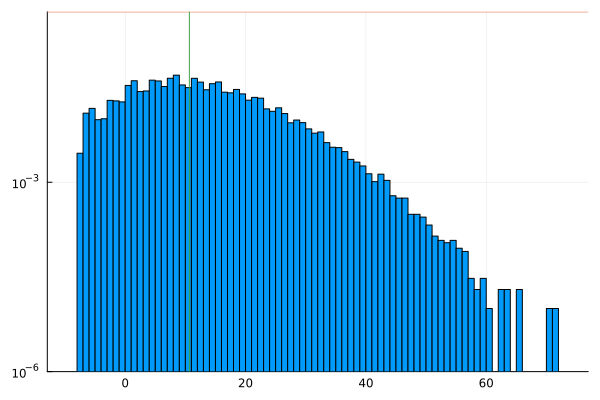

In [199]:
test_statistics = []
for n in 1:100000
    test_statistic = 0
    for (idx,cosmo_rate) in enumerate(cosmo_rates)
        nbs = rand(Poisson(cosmo_rate),1)
        background_likelihood = likelihood(nbs[1],rates[idx])
        signal_likelihood = likelihood(nbs[1],cosmo_rate)
        test_statistic += -2 * log(background_likelihood / signal_likelihood)
    end
    push!(test_statistics,test_statistic)
end
histogram(test_statistics,label="",normed=true,bins=100,yscale=:log10)
hline!([1-0.5],label="")
vline!([quantile(test_statistics,0.50)],label="")

In [200]:
quantile(test_statistics,0.5)

10.664341131998059

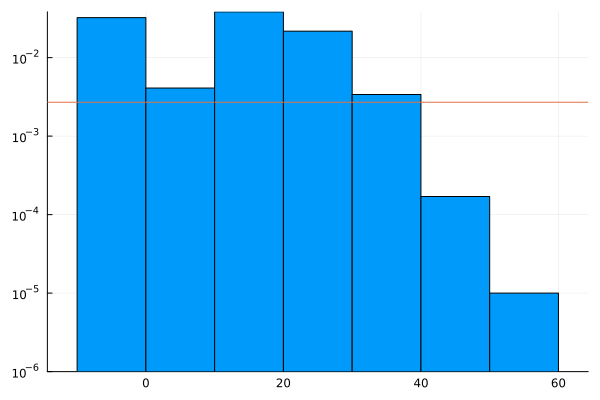

In [176]:
n = 10_000
nbs = rand(Poisson(16.),n)
test_statistics = []
small_nbs = []
for nb in nbs 
    background_likelihood = likelihood(nb,5.4)
    signal_likelihood = likelihood(nb,16.)
    test = -2 * log(background_likelihood / signal_likelihood)
    if test < 0 
        push!(small_nbs,nb)
    end 
    if nb - 14 <= 0 
        push!(test_statistics,2 * log(background_likelihood / signal_likelihood))
    else
        push!(test_statistics,-2 * log(background_likelihood/signal_likelihood))
    end
end
histogram(test_statistics,label="",normed=true,bins=10,yscale=:log10)
hline!([2.7e-3],label="")

In [153]:
likelihood(7,5.3)

0.1163428763490066

In [120]:
function likelihood(x::Int64,μ::Float64)
    return pdf(Poisson(μ),x)
end

function poisson_sampler(μ::Float64,n::Int64)
    return rand(Poisson(μ),n)
end

poisson_sampler (generic function with 1 method)

In [520]:
using PyCall
py"""
import sys
sys.path.append("/Users/pavelzhelnin/Downloads/flux_plot/src")
from plot_nu_flux_earth_fluxes import read_flux_data
"""

In [524]:
flux_labels = ["heinze_zmax_1", "van_vliet_ta", "rodrigues_bench_cosmo", 
               "rodrigues_bench_source", "rodrigues_hlbllacs_cosmo", 
               "fang_murase", "fang_pulsar_sfr", "padovani_2015", "muzio_2019",
               "muzio_2021"]

10-element Vector{String}:
 "heinze_zmax_1"
 "van_vliet_ta"
 "rodrigues_bench_cosmo"
 "rodrigues_bench_source"
 "rodrigues_hlbllacs_cosmo"
 "fang_murase"
 "fang_pulsar_sfr"
 "padovani_2015"
 "muzio_2019"
 "muzio_2021"

In [617]:
cosmo_flux_labels = ["rodrigues_bench_cosmo","heinze_zmax_1","rodrigues_hlbllacs_cosmo","van_vliet_ta"]

4-element Vector{String}:
 "rodrigues_bench_cosmo"
 "heinze_zmax_1"
 "rodrigues_hlbllacs_cosmo"
 "van_vliet_ta"

In [627]:
source_flux_labels = ["fang_pulsar_sfr","rodrigues_bench_source", "padovani_2015"]

3-element Vector{String}:
 "fang_pulsar_sfr"
 "rodrigues_bench_source"
 "padovani_2015"

In [632]:
both_flux_labels = ["muzio_2019","fang_murase", "muzio_2021"]

3-element Vector{String}:
 "muzio_2019"
 "fang_murase"
 "muzio_2021"

In [560]:
# # Append the directory to the Python system path
py""" 
def load_Mauricio_data(flux_label):
    print(flux_label)

    # Call the read_flux_data Python function from the module
    energy, flux_nu, flux_nubar = read_flux_data(flux_label)
    nutau_flux =  (flux_nu + flux_nubar) / energy**2
    return energy, nutau_flux
"""

In [561]:
function spline_mauricio(flux_label)
    energy, flux = py"load_Mauricio_data"(flux_label)
    return Spline1D(energy,flux)
end

spline_mauricio (generic function with 1 method)

Differential Sensitivity Plot

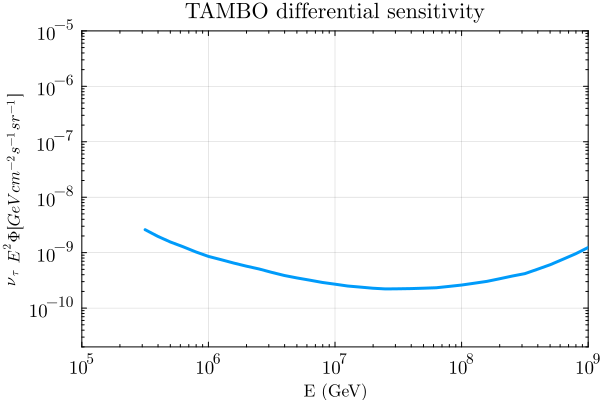

"/Users/pavelzhelnin/Documents/physics/TAMBO/notebooks/TAMBO_diff_sens.pdf"

In [420]:
#edges = 10 .^ (14.5:1.0:18.5)
#edges = 10 .^ (14.9:0.2:17.1)
low_edges = 10 .^ (14.0:0.1:17.5)
high_edges = 10 .^ (15.0:0.1:18.5)
#cents = 10 .^ ((log10.(edges[1:end-1]) .+ log10.(edges[2:end])) / 2)
cents = 10 .^ (14.5:0.1:18)
norm_factors = Vector{Float64}([])
rw_norm_factors = Vector{Float64}([])
#for (idx,edge) in enumerate(edges[1:end-1])
for (idx,edge) in enumerate(high_edges) 
    # println("edge: ", edge)
    #mask = edge .< energies .< edges[idx+1]
    mask = low_edges[idx] .< energies .< edge
    
    if length(energies[mask]) == 0
        println("no events in bin")
        continue
    end

    diff_rates = combined_calc_triggered_event_rate(e_all_events[mask]; γ=2, ϕ=1.0, norm_e=cents[idx])[1]
    bg_diff_rates = combined_calc_triggered_event_rate(e_all_events[mask]; γ=2.52, ϕ=1.8e-18, norm_e=100units.TeV)[1]
    
    rw_diff_rates, _ = quadgk(e-> diff_integrand(e, cents[idx]/1e9, 2), low_edges[idx]/1e9, edge/1e9)
    #push!(rw_norm_factors, 2.44 / (rw_diff_rates* 10 * 10^7.5) ) 
    push!(rw_norm_factors, 2.44 / (rw_diff_rates* 10 * 10^7.5) ) 
    #FC 90% sensitivity = 2.44 events 
    norm_factor = 1.00 /  sum(diff_rates * (5000/nmodules) * 10 * 10^7.5 * units.second)

    push!(norm_factors,norm_factor)

end
#display(rw_norm_factors)
rw_diff_sens = (1/3).* rw_norm_factors
diff_sens = (1/3).* norm_factors 
#display(rw_diff_sens)
plt = plot(
    xscale=:log,
    yscale=:log,
    xlabel="E (GeV)",
    xminorticks=true,
    yminorticks=true,
    ylabel="\$ \\nu_\\tau \$ \$E^{2}\\Phi [GeV cm^{-2} s^{-1} sr^{-1}]\$",
    xlimits=(1e5, 1e9),
    title="TAMBO differential sensitivity",
    ylimits=(2e-11,1e-5),
    legend=:topleft,
    framestyle=:box,
    tickfontsize=12,
    # left_margin=5mm,
    # right_margin=5mm,
    # bottom_margin=5mm,
    fontfamily="Computer Modern",
    size=(600, 400)   
)


plot!(
    plt,
    #edges / units.GeV,
    cents / units.GeV,
    #log.(10, (cents / units.GeV).^ 2 .* diff_sens),
    (cents / units.GeV).^ 2 .* diff_sens,
    # hist_three.weights .*norm_factors,
    #linetype=:stepbins,
    linetype=:line,
    label="",
    lw=3
    )

# plot!(
#         plt,
#         #edges / units.GeV,
#         cents / units.GeV,
#         #log.(10, (cents / units.GeV).^ 2 .* diff_sens),
#         (cents / units.GeV).^ 2 .* rw_diff_sens,
#         # hist_three.weights .*norm_factors,
#         #linetype=:stepbins,
#         linetype=:line,
#         label="redid SnowMass paper in Julia today",
#         lw=3
#         )

# csv_energies = [1.00E+06,1.58E+06,2.51E+06,3.98E+06,6.31E+06,1.00E+07,1.58E+07,2.51E+07,3.98E+07,6.31E+07,1.00E+08]
# csv_diff_sens = [2.57E-09,1.90E-09,1.47E-09,1.18E-09,9.96E-10,8.81E-10,8.10E-10,7.74E-10,7.73E-10,8.32E-10,9.58E-10]

# plot!(
#     plt,
#     csv_energies,
#     csv_diff_sens,
#     linetype=:line,
#     label="0.1 \$ \\times \$ SnowMass paper",
#     lw=3
#     )

display(plt)
savefig(plt,"TAMBO_diff_sens.pdf")

In [326]:
Romero = [14.50169082125604, 37.75837252032834,
14.55439534331195, 48.10229456381409,
14.607099865367863, 61.77376039091001,
14.659804387423774, 79.11892513871553,
14.713946305535757, 103.37438060998585,
14.7652134315356, 130.8334448113505,
14.817917953591511, 168.24337636151847,
14.870622475647423, 216.06092002381354,
14.923326997703334, 277.4689986084595,
14.976031519759246, 363.0663984598983,
15.028736041815158, 435.50755201015795,
15.08144056387107, 534.4185542340056,
15.134145085926983, 642.7662535925228,
15.186849607982895, 777.2279676741465,
15.239554130038806, 939.8180292735774,
15.292258652094718, 1130.3561767250592,
15.34496317415063, 1364.9907583497388,
15.397667696206542, 1646.1263127102234,
15.450372218262455, 1982.511201471991,
15.503076740318367, 2387.636133153652,
15.555781262374278, 2856.3792501391035,
15.60848578443019, 3412.5784444736237,
15.661190306486102, 4071.6314825846016,
15.713894828542013, 4857.963911956672,
15.766599350597925, 5803.915194092913,
15.819303872653837, 6924.794319318539,
15.872008394709749, 8262.142840004195,
15.924712916765662, 9857.766333679378,
15.977417438821574, 11935.890476806726,
16.030121960877487, 13499.02862169758,
16.0828264829334, 15472.473342245183,
16.13553100498931, 17592.649445384468,
16.188235527045222, 20003.35096155187,
16.240940049101134, 22653.296067843283,
16.293644571157046, 25791.931106084045,
16.346349093212957, 29247.817187787852,
16.39905361526887, 33211.15749628182,
16.45175813732478, 37913.89277877971,
16.504462659380692, 42479.50020079012,
16.557167181436604, 48171.3699913005,
16.609871703492516, 54334.38860150988,
16.662576225548428, 61122.155983886354,
16.71528074760434, 68942.09103852251,
16.76798526966025, 77762.50428759343,
16.820689791716163, 87477.04794513575,
16.873394313772074, 98536.91294420509,
16.92609883582799, 110995.09460657036,
16.9788033578839, 126035.920719331,
17.01234259919221, 130147.91494092306,
#17.5, 5e5
]

98-element Vector{Float64}:
     14.50169082125604
     37.75837252032834
     14.55439534331195
     48.10229456381409
     14.607099865367863
     61.77376039091001
     14.659804387423774
     79.11892513871553
     14.713946305535757
    103.37438060998585
      ⋮
  87477.04794513575
     16.873394313772074
  98536.91294420509
     16.92609883582799
 110995.09460657036
     16.9788033578839
 126035.920719331
     17.01234259919221
 130147.91494092306

In [327]:
using Dierckx
using QuadGK

In [328]:
energy_log= [] # log scale in eV
energy_GeV = [] # not log scale in GeV
acceptance_romero = []
for (i,x) in enumerate(Romero)
    if i%2 == 1
        append!(energy_log,x)
        append!(energy_GeV, 10^(x-9))
    else 
        append!(acceptance_romero,x)
    end
end 

In [329]:
spl = Spline1D(energy_GeV,acceptance_romero)

Spline1D(knots=[3.17461e5,4.04669e5 … 8.43527e7,1.02883e8] (47 elements), k=3, extrapolation="nearest", residual=0.0)

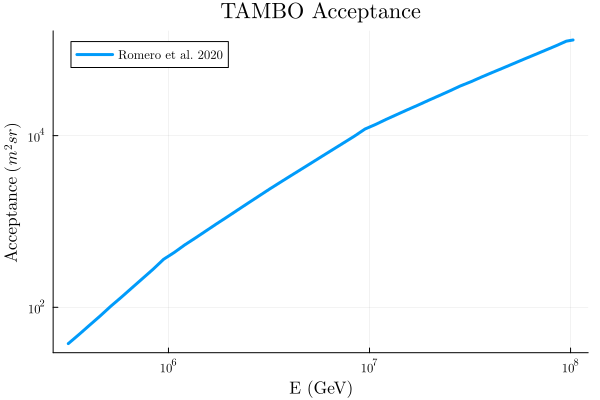

In [330]:
plot([energy_GeV],[acceptance_romero],
label="Romero et al. 2020",lw=3,
legend=:topleft,yscale=:log10,
xscale=:log10,xlabel="E (GeV)",
fontfamily="Computer Modern",
ylabel="Acceptance \$(m^2 sr)\$",
title="TAMBO Acceptance")

In [331]:
function acceptance(E)
    # if E < 10^(14.5-9) || E > 10^(17.01-9) 
    #     return 0 
    # end 
    #return 10^4 * 400 * ((E/10^6)^1.5)
    return 10^4 * spl(E) #(cm^2 sr^1)
    end 
function flux(E)
    return (1/3) * 6.7*10^-18 * ((E/10^5)^-2.5) #(GeV) (GeV-1,s^-1,sr^-1,cm^-2)
end 
t = 9.461*10^7 #amount of s in 3 yrs
#integral_bounds = 10^7, 10^6 
function integrand(E)
    return acceptance(E)*flux(E)*t 
end 

function diff_integrand(E,E_norm,γ)
    return acceptance(E)*(E/E_norm)^-γ
end
Ef = 10^8.25

Ein = 10^5.5
result = quadgk(e -> exp(e)*integrand(exp(e)),log(Ein),log(Ef))
#result = integrate.quad(lambda e: np.exp(e) * integrand(np.exp(e)),np.log(Ein),np.log(Ef))
result

(12.704868775821048, 1.8534505150883535e-7)

In [195]:
new_result = []
bins = range(start=5.25,stop=8.25,length=7)
for (i,x) in enumerate(bins)
    if i == 6
        break
    end 
    z,y = quadgk(e-> integrand(e),10^bins[i],10^bins[i+1])
    append!(new_result,z)
end

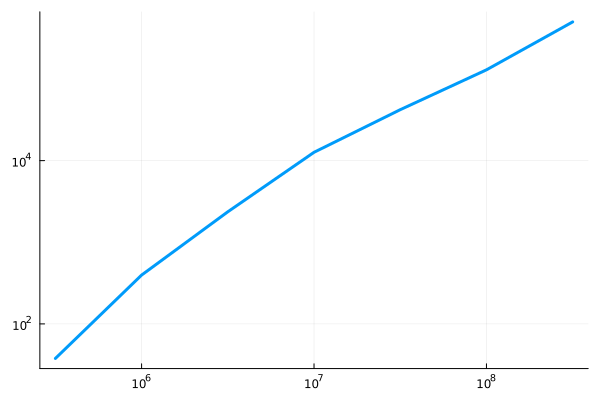

In [324]:
E = 10 .^(5.5:0.5:8.5)
plot(E,spl(E),xscale=:log10,lw=3,yscale=:log10,label="")

In [431]:
δ = 0.1 
Δ = 0.1
τs = δ*(-50:1:50)
xs = [] 
ys = []
Bx = [] 
for τ in τs 
    integral = quadgk(x -> sqrt(x^2+Δ^2),0,τ)[1]
    θdot = Δ/(τ^2 + Δ^2)
    H = sqrt(τ^2 +Δ^2)
    a = -im/(2*H) * 1/4 * θdot^2
    result = -4*δ*(H/θdot)*a*exp(-2im/δ * integral)
    append!(Bx, [normalize([Δ,0,τ])][1][1])
    append!(xs,real(result))
    append!(ys,imag(result))
    #other_result = conj(result)
    println("τ: $τ, result: $result")
end

τ: -5.0, result: 0.0001457458563321343 + 0.00013684357694746947im
τ: -4.9, result: -0.0002002439683217953 - 5.685844957122458e-5im
τ: -4.8, result: 0.0002169196980319646 - 1.3444566642078248e-7im
τ: -4.7, result: -0.0002255573925230277 + 1.7617202418775214e-5im
τ: -4.6, result: 0.00023594756398693416 + 1.054931093581981e-5im
τ: -4.5, result: -0.00023033423443943925 - 8.861313380845916e-5im
τ: -4.4, result: 0.00016251256824154078 + 0.00020055260096987583im
τ: -4.3, result: 1.1206226404270415e-5 - 0.0002700378482393555im
τ: -4.2, result: -0.00023269749410096975 + 0.0001615639237143495im
τ: -4.1, result: 0.0002586385122995039 + 0.0001465356462311316im
τ: -4.0, result: 8.239369024470167e-5 - 0.0003012400601530035im
τ: -3.9, result: -0.00032070883596190246 - 7.11900354546235e-5im
τ: -3.8, result: -0.00012506835163991005 + 0.000322627144907418im
τ: -3.7, result: 0.0002741082870866038 + 0.00024096266504723348im
τ: -3.6, result: 0.00036846667346553374 - 0.00011334206847896542im
τ: -3.5, result

In [8]:
using LinearAlgebra

In [ ]:
using powerlaws 

In [97]:
function poisson_likelihood(x)
    -2 * log(pdf(Poisson(5.4),5)/pdf(Poisson(5.4+x),8))
end 

poisson_likelihood (generic function with 1 method)

In [102]:
poisson_likelihood(2)

1.0412967462383267

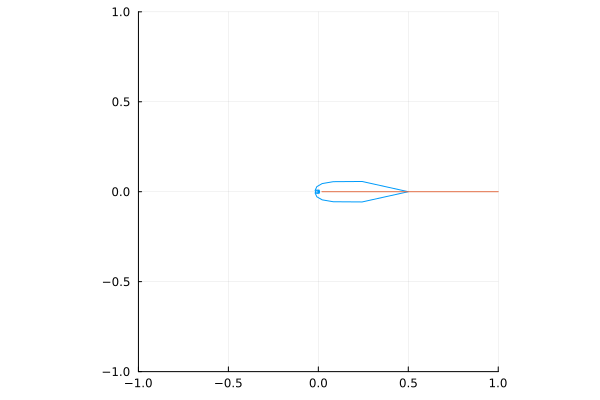

In [432]:
last=101
plot(ys[1:last],xs[1:last],xlimit=(-1,1),ylimit=(-1,1),label="",aspect_ratio=:equal)
plot!(Bx,zeros(length(τs)),label="")

In [750]:
function acoef(n,wc,τ)
    w = 2 * quadgk(x -> sqrt(x^2+τ^2),0,τ)[1]
    return ((factorial(n)*im^(n+1))/ 2pi) * (1/(w-wc)^(n+1) - 1/(w-conj(wc))^(n+1))
end

acoef (generic function with 1 method)

In [6]:
using QuadGK

In [46]:
δ = 0.1 
Δ = 0.1
τs = δ*(-50:1:50)
xs = [] 
ys = []
Bx = [] 
n = 0
wc = -im * pi/2
for τ in τs 
    w = 2 * quadgk(x -> sqrt(Δ^2+x^2),0,τ)[1]
    aθ = 1/(pi) * factorial(n) * im^(n) * (1/(w-wc)^(n+1) - 1/(w-conj(wc))^(n+1))
    H = sqrt(τ^2 +Δ^2)
    result = -δ^(n+1)*(H)*aθ*exp(-w*im/δ)
    append!(Bx, [normalize([Δ,0,τ])][1][1])
    append!(xs,real(result))
    append!(ys,imag(result))
    #other_result = conj(result)
    println("τ: $τ, result: $result")
end

τ: -5.0, result: 0.0005786828461982285 + 0.0005433364116469101im
τ: -4.9, result: -0.000810923631956966 - 0.00023025842336306157im
τ: -4.8, result: 0.0008963097681107955 - 5.555279911964548e-7im
τ: -4.7, result: -0.000951311410821813 + 7.4302356044604e-5im
τ: -4.6, result: 0.0010161575507927332 + 4.5432814740512735e-5im
τ: -4.5, result: -0.0010133583037342739 - 0.00038985457451971026im
τ: -4.4, result: 0.0007306936713539734 + 0.000901730357768107im
τ: -4.3, result: 5.151602848894037e-5 - 0.0012413882230408579im
τ: -4.2, result: -0.0010942232201445951 + 0.0007597288382882266im
τ: -4.1, result: 0.0012446326511213071 + 0.0007051658634705385im
τ: -4.0, result: 0.00040596075789383175 - 0.0014842355375091893im
τ: -3.9, result: -0.0016186652318749793 - 0.00035930670541311447im
τ: -3.8, result: -0.0006469469849033963 + 0.0016688687098619932im
τ: -3.7, result: 0.0014539264178851676 + 0.00127811525933719im
τ: -3.6, result: 0.0020051424633925684 - 0.0006167911802128839im
τ: -3.5, result: 0.000996

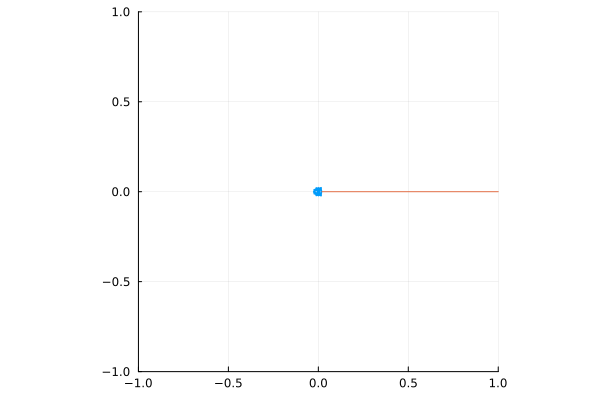

In [47]:
plot(-ys,xs,xlimit=(-1,1),ylimit=(-1,1),label="",aspect_ratio=:equal)
plot!(Bx,zeros(length(τs)),label="")

In [43]:
(1/(0-wc)^(0+1) - 1/(0-conj(wc))^(0+1))

0.0 - 1.2732395447351628im